# Logistic Regression на NumPy с нуля

Разбирается бинарная классификация на Iris без `sklearn.linear_model`,
только на базовой математике NumPy.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


from pathlib import Path

def find_repo_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "notebooks").exists() and (candidate / "requirements.txt").exists():
            return candidate
    return current.parent if current.name == "notebooks" else current

REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "data"
FIGURES_DIR = REPO_ROOT / "figures" / "logistic_regression"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
(DATA_DIR / 'logistic_regression').mkdir(parents=True, exist_ok=True)

 

np.random.seed(42)
print('NumPy:', np.__version__)
print('pandas:', pd.__version__)

NumPy: 2.4.6
pandas: 2.3.3


In [2]:
# Загрузка данных и первичная подготовка
iris_path = DATA_DIR / 'logistic_regression' / 'iris_binary.csv'
df = pd.read_csv(iris_path)

print('Файл:', iris_path)
print('Размер датасета:', df.shape)
print('Распределение по целевой переменной:\n', df['target'].value_counts())
df.head()

Файл: /Users/nailloon/Documents/Projects/study/deep_learning/repository/data/logistic_regression/iris_binary.csv
Размер датасета: (100, 5)
Распределение по целевой переменной:
 target
0    50
1    50
Name: count, dtype: int64


,sepal_length,sepal_width,petal_length,petal_width,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
# Выбираем признаки
FEATURES = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
TARGET = 'target'

data = df[FEATURES + [TARGET]].copy()
print('Пропуски по столбцам:\n', data.isnull().sum())

X = data[FEATURES].values.astype(np.float64)
y = data[TARGET].values.astype(np.float64).reshape(-1, 1)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Нормализацию считаем только по train, чтобы не было утечки из validation.
train_means = X_train.mean(axis=0, keepdims=True)
train_stds = np.where(X_train.std(axis=0, keepdims=True) == 0, 1.0, X_train.std(axis=0, keepdims=True))
X_train = (X_train - train_means) / train_stds
X_val = (X_val - train_means) / train_stds

print(f'Обучающая выборка: {X_train.shape}')
print(f'Проверочная выборка: {X_val.shape}')
print(f'Доля положительного класса в train: {y_train.mean():.3f}')
print(f'Доля положительного класса в val:   {y_val.mean():.3f}')

Пропуски по столбцам:
 sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
target          0
dtype: int64
Обучающая выборка: (80, 4)
Проверочная выборка: (20, 4)
Доля положительного класса в train: 0.500
Доля положительного класса в val:   0.500


In [4]:
# Реализация модели на чистом NumPy
def sigmoid(z: np.ndarray) -> np.ndarray:
    """Численно устойчивая сигмоида."""
    return np.where(
        z >= 0,
        1.0 / (1.0 + np.exp(-z)),
        np.exp(z) / (1.0 + np.exp(z))
    )


def bce_loss(y_true: np.ndarray, y_pred: np.ndarray, eps: float = 1e-9) -> float:
    """Считает Binary Cross-Entropy как одно число."""
    y_pred = np.clip(y_pred, eps, 1.0 - eps)
    n = y_true.shape[0]
    loss = -np.sum(
        y_true * np.log(y_pred) + (1.0 - y_true) * np.log(1.0 - y_pred)
    ) / n
    return float(loss)


def compute_gradients(
    X: np.ndarray,
    y_true: np.ndarray,
    y_pred: np.ndarray
):
    """Аналитические градиенты dL/dw и dL/db."""
    n = X.shape[0]
    error = (y_pred - y_true) / n
    dw = X.T @ error
    db = np.sum(error)
    return dw, db


def predict(X: np.ndarray, weights: np.ndarray, bias: float) -> np.ndarray:
    """Возвращает вероятности принадлежности к классу 1."""
    z = np.clip(X @ weights + bias, -40.0, 40.0)
    return sigmoid(z)


print('Функции модели готовы.')
assert abs(sigmoid(np.array([0.0]))[0] - 0.5) < 1e-9, 'sigmoid(0) должно быть 0.5'
print('Проверка sigmoid(0):', sigmoid(np.array([0.0]))[0])

Функции модели готовы.
Проверка sigmoid(0): 0.5


In [5]:
# Цикл обучения (mini-batch SGD)
EPOCHS = 100
LR = 0.02
BATCH_SIZE = 32

n_features = X_train.shape[1]
n_train = X_train.shape[0]

weights = np.zeros((n_features, 1), dtype=np.float64)
bias = 0.0

train_losses = []
val_losses = []

for epoch in range(1, EPOCHS + 1):
    permutation = np.random.permutation(n_train)

    for start in range(0, n_train, BATCH_SIZE):
        batch_idx = permutation[start:start + BATCH_SIZE]
        X_batch = X_train[batch_idx]
        y_batch = y_train[batch_idx]

        y_pred_batch = predict(X_batch, weights, bias)
        dw, db = compute_gradients(X_batch, y_batch, y_pred_batch)
        dw = np.clip(dw, -1.0, 1.0)
        db = float(np.clip(db, -1.0, 1.0))

        weights -= LR * dw
        bias -= LR * db

    y_pred_train = predict(X_train, weights, bias)
    y_pred_val = predict(X_val, weights, bias)

    loss_train = bce_loss(y_train, y_pred_train)
    loss_val = bce_loss(y_val, y_pred_val)

    train_losses.append(loss_train)
    val_losses.append(loss_val)

    if epoch % 50 == 0:
        print(
            f'Эпоха {epoch:4d}/{EPOCHS}  '
            f'train_loss={loss_train:.4f}  '
            f'val_loss={loss_val:.4f}'
        )

print('\nОбучение завершено.')

Эпоха   50/100  train_loss=0.1352  val_loss=0.1395
Эпоха  100/100  train_loss=0.0735  val_loss=0.0796

Обучение завершено.


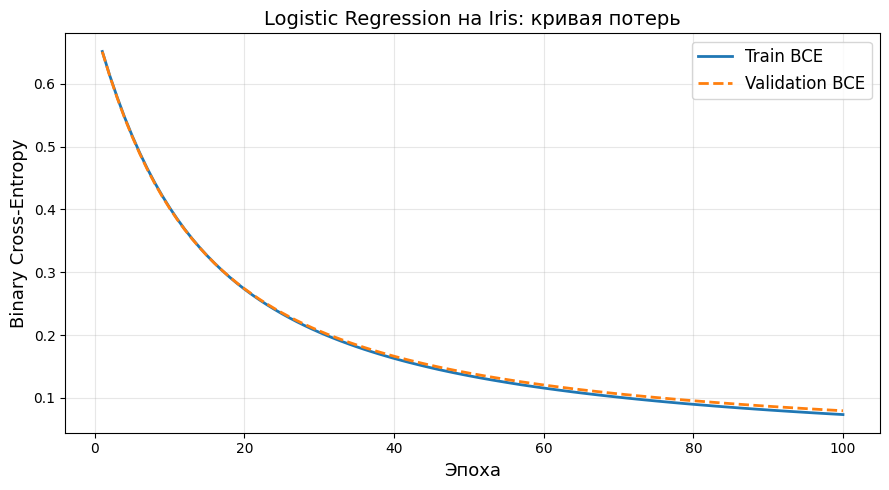

Финальная train loss: 0.0735
Финальная val loss:   0.0796


In [6]:
# График функции потерь
epochs_range = np.arange(1, EPOCHS + 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(epochs_range, train_losses, label='Train BCE', linewidth=2)
ax.plot(epochs_range, val_losses, label='Validation BCE', linewidth=2, linestyle='--')
ax.set_xlabel('Эпоха', fontsize=13)
ax.set_ylabel('Binary Cross-Entropy', fontsize=13)
ax.set_title('Logistic Regression на Iris: кривая потерь', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'loss_curve.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Финальная train loss: {train_losses[-1]:.4f}')
print(f'Финальная val loss:   {val_losses[-1]:.4f}')

Train accuracy: 100.00%
Val accuracy:   100.00%
Порог выполнен: validation accuracy >= 70%  (100.00%)

Матрица ошибок (threshold=0.5):
  TP=10  FP=0
  FN=0  TN=10

Precision: 1.0000
Recall:    1.0000
F1 score:  1.0000


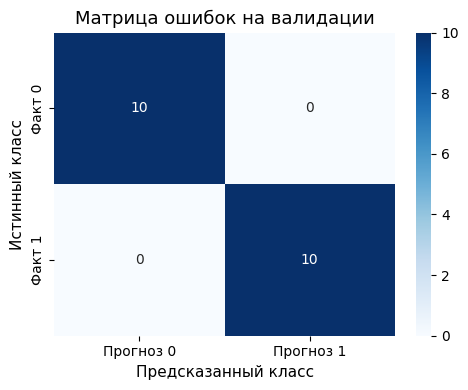

In [7]:
# Проверка качества
def accuracy(y_true: np.ndarray, probs: np.ndarray, threshold: float = 0.5) -> float:
    preds = (probs >= threshold).astype(int)
    return float(np.mean(preds == y_true))


val_probs = predict(X_val, weights, bias)
val_accuracy = accuracy(y_val, val_probs)

train_probs = predict(X_train, weights, bias)
train_accuracy = accuracy(y_train, train_probs)

print(f'Train accuracy: {train_accuracy * 100:.2f}%')
print(f'Val accuracy:   {val_accuracy * 100:.2f}%')

assert val_accuracy >= 0.70, (
    f'Validation accuracy {val_accuracy:.3f} ниже порога 70%.'
)
print(f'Порог выполнен: validation accuracy >= 70%  ({val_accuracy * 100:.2f}%)')

val_preds = (val_probs >= 0.5).astype(int)

tp = int(np.sum((val_preds == 1) & (y_val == 1)))
tn = int(np.sum((val_preds == 0) & (y_val == 0)))
fp = int(np.sum((val_preds == 1) & (y_val == 0)))
fn = int(np.sum((val_preds == 0) & (y_val == 1)))

precision = tp / (tp + fp + 1e-9)
recall = tp / (tp + fn + 1e-9)
f1 = 2 * precision * recall / (precision + recall + 1e-9)

print('\nМатрица ошибок (threshold=0.5):')
print(f'  TP={tp}  FP={fp}')
print(f'  FN={fn}  TN={tn}')
print(f'\nPrecision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1 score:  {f1:.4f}')

cm = np.array([[tn, fp], [fn, tp]])

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Прогноз 0', 'Прогноз 1'],
    yticklabels=['Факт 0', 'Факт 1'],
    ax=ax
)
ax.set_title('Матрица ошибок на валидации', fontsize=13)
ax.set_ylabel('Истинный класс', fontsize=11)
ax.set_xlabel('Предсказанный класс', fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()